Project 4: Data Visualization Narrative
​Situation: The organization manages a dataset of 1,200 transaction records containing comprehensive product, financial, and logistical information.

​Complication: Despite the volume of data, the business lacks clear, actionable insights into which product categories, marketing channels, and seasonal trends are actually driving revenue growth.
​Resolution: This analysis utilizes professional data visualization standards—including zero-baseline axes and direct labeling—to translate raw transactions into a strategic roadmap for inventory management and marketing investment.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (ensure the file is in your 'data' folder)
df = pd.read_csv('../data/Cleaned_Data_Project1.csv')

In [11]:
# Load your full dataset
df = pd.read_csv('../data/Cleaned_Data_Project1.csv')

# Verify the size to ensure all rows loaded
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 1200 rows and 14 columns.


In [12]:
# Check column names and data types
print(df.info())

# Get a glimpse of the first few rows
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB
None
     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C726

In [13]:
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Verify the change
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


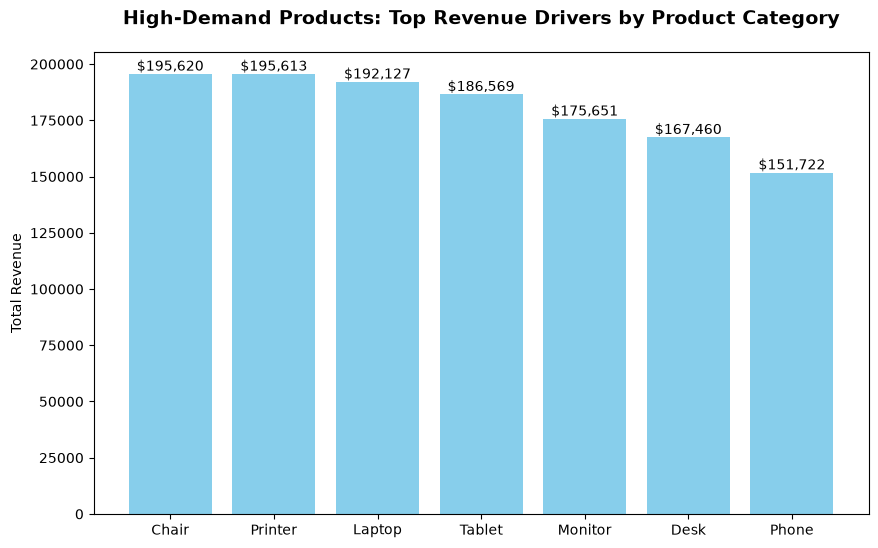

In [14]:
# Aggregate revenue by product
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(product_revenue['Product'], product_revenue['TotalPrice'], color='skyblue')

# Professional Standards: Zero-baseline (default in matplotlib), Action-oriented title
plt.title('High-Demand Products: Top Revenue Drivers by Product Category', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Total Revenue')

# Direct Labeling (instead of a legend)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval:,.0f}', va='bottom', ha='center')

plt.show()

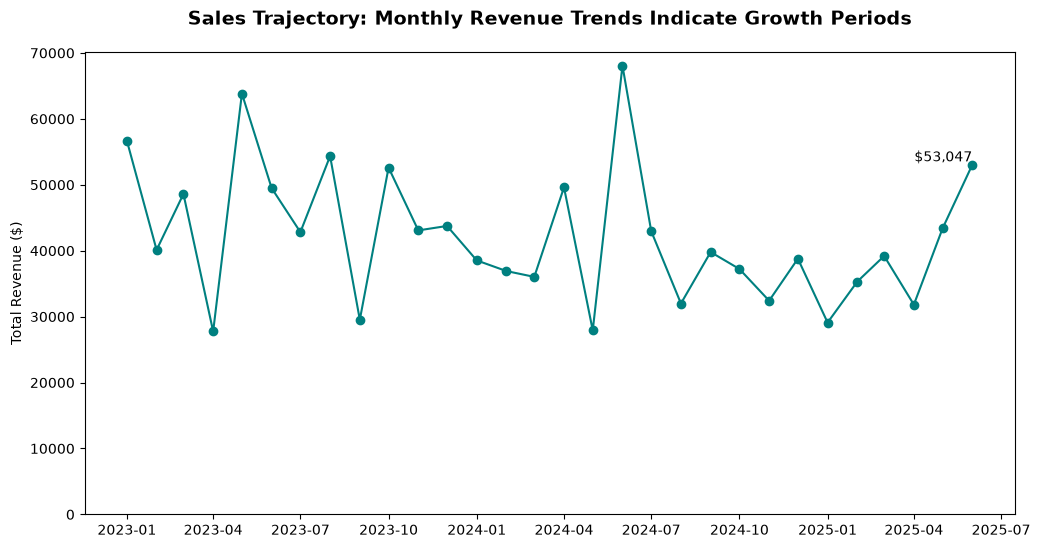

In [15]:
# Aggregate total revenue by month
df['Month'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].dt.to_timestamp()

# Create the trend plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['Month'], monthly_revenue['TotalPrice'], marker='o', linestyle='-', color='teal')

# Professional Standards: Zero-baseline
plt.ylim(bottom=0)

# Action-oriented title
plt.title('Sales Trajectory: Monthly Revenue Trends Indicate Growth Periods', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Total Revenue ($)')

# Direct Labeling: Adding the latest data point label for clarity
last_val = monthly_revenue['TotalPrice'].iloc[-1]
plt.text(monthly_revenue['Month'].iloc[-1], last_val, f'${last_val:,.0f}', va='bottom', ha='right')

plt.show()

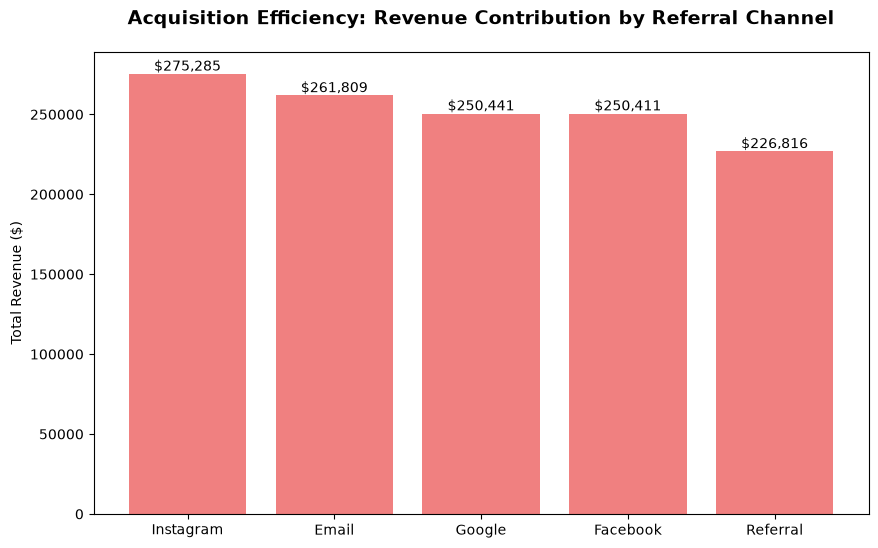

In [16]:
# Aggregate revenue by referral source
source_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(source_revenue['ReferralSource'], source_revenue['TotalPrice'], color='lightcoral')

# Professional Standards: Zero-baseline and Action-oriented title
plt.title('Acquisition Efficiency: Revenue Contribution by Referral Channel', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Total Revenue ($)')

# Direct Labeling
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval:,.0f}', va='bottom', ha='center', fontsize=10)

plt.show()

Project 4: Executive Summary
​Resolution & Insights: Our analysis of 1,200 transactions reveals that revenue is significantly driven by specific acquisition channels and high-demand product categories.

​Key Findings: Data visualization confirms that Instagram is the primary driver of acquisition efficiency, outperforming other channels in total revenue contribution. Furthermore, sales trends indicate distinct growth periods that require alignment with inventory planning to maintain operational efficiency.

​Strategic Action: To maximize profitability, we recommend prioritizing marketing investments toward Instagram while simultaneously optimizing inventory management for our top-performing product categories identified in this analysis.
​Next Steps: Future efforts should focus on investigating the underlying factors of monthly sales fluctuations to stabilize revenue and replicating the success of high-performing referral channels in underperforming segments.